In [11]:
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import numpy as np
import jdcal as j 
from astropy.time import Time

In [12]:
map_satire = np.load('/home/sophie-stucki/starsim/starsim/SDO_input/spots_satire.npy', allow_pickle=True).item()

ff_sp_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/ff_sp_test_mps.txt')


In [13]:
umbra = []
penumbra = []
days_satire = []
#todo check if it's really daily !!!
for item in map_satire.keys():
    days_satire.append((Time(item.replace('/scratch/HF/masks/', '').replace('_TAI_bmu_mask.sav', '').replace('.', '-').replace('_', 'T'), format='isot')-Time('2010-05-01T01:00:00', format='isot')).value)
    umbra.append(map_satire[item]['umbra'])
    penumbra.append(map_satire[item]['penumbra'])

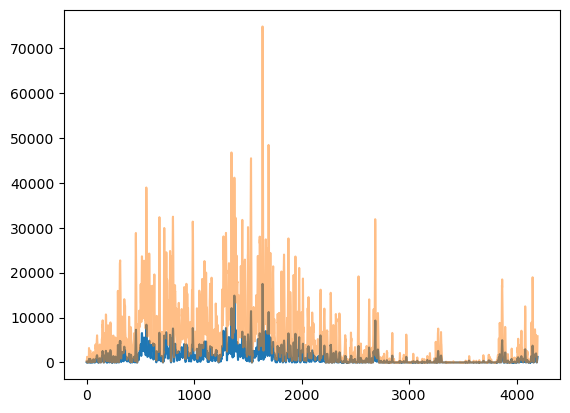

In [14]:
plt.plot(days_satire, umbra)
plt.plot(days_satire, penumbra, alpha=0.5)

In [15]:
test_umbra = []
test_penumbra = []
test_days_satire = []
#todo check if it's really daily !!!
for item in map_satire.keys():
    delta_d = (Time(item.replace('/scratch/HF/masks/', '').replace('_TAI_bmu_mask.sav', '').replace('.', '-').replace('_', 'T'), format='isot')-Time('2017-07-01T01:00:00', format='isot')).value
    if delta_d >= 0 and delta_d<=62:
        test_days_satire.append(delta_d)
        test_umbra.append(map_satire[item]['umbra'])
        test_penumbra.append(map_satire[item]['penumbra'])

test_penumbra = np.array(test_penumbra)
test_umbra = np.array(test_umbra)


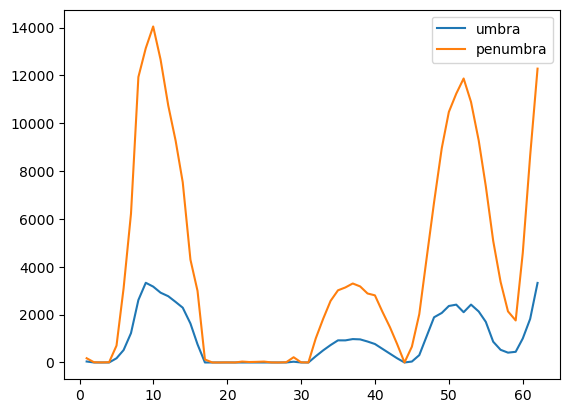

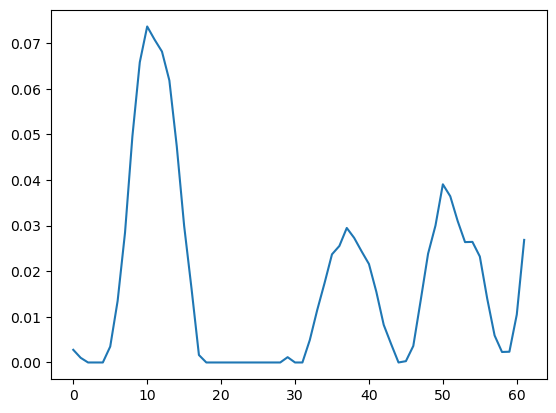

In [16]:
plt.plot(test_days_satire, test_umbra, label='umbra')
plt.plot(test_days_satire, test_penumbra, label='penumbra')
plt.legend()
plt.show()
plt.plot(ff_sp_mps)

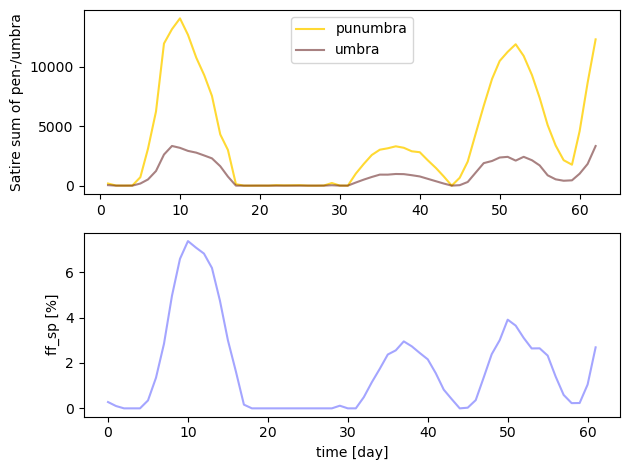

In [17]:
fig, axs = plt.subplots(2,1)

# First Y-axis
axs[0].set_ylabel('Satire sum of pen-/umbra')
axs[0].plot(test_days_satire, test_penumbra, color = "#ffd000", label='punumbra', alpha=0.8)
axs[0].plot(test_days_satire, test_umbra, color = "#520505", label='umbra', alpha=0.5)
axs[0].legend()

# Second Y-axis sharing the same X-axis

axs[1].set_ylabel('ff_sp [%]')
axs[1].plot(ff_sp_mps * 100, color="#686aff", alpha=0.6)
axs[1].tick_params(axis='y')
axs[1].set_xlabel('time [day]')

plt.tight_layout()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comp_satire_ff,png')
plt.show()


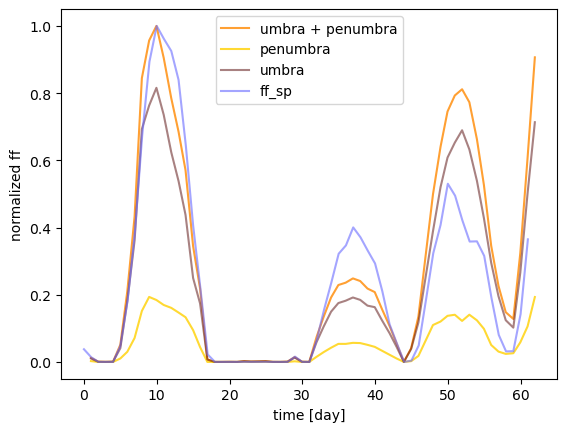

In [18]:
plt.plot(test_days_satire, (test_penumbra + test_umbra) / np.max(test_penumbra + test_umbra), color = "#ff8800", label='umbra + penumbra', alpha=0.8)
plt.plot(test_days_satire, (test_umbra) / np.max(test_penumbra + test_umbra), color = "#ffd000", label='penumbra', alpha=0.8)
plt.plot(test_days_satire, (test_penumbra) / np.max(test_penumbra + test_umbra), color = "#520505", label='umbra', alpha=0.5)
plt.plot(ff_sp_mps / np.max(ff_sp_mps),  color="#686aff", alpha=0.6, label='ff_sp')
plt.legend()
plt.ylabel('normalized ff')
plt.xlabel('time [day]')
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comp_satire_ff_norm,png')


In [19]:
test_ff_sp = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/maps_I_th_test/ff_sp.txt')

Text(0.5, 0, 'time [day]')

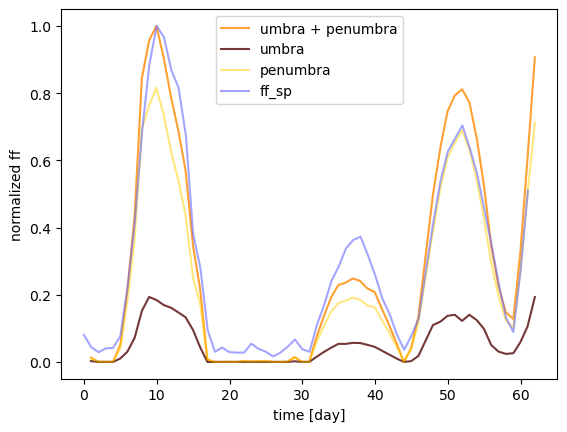

In [25]:
plt.plot(test_days_satire, (test_penumbra + test_umbra) / np.max(test_penumbra + test_umbra), color = "#ff8800", label='umbra + penumbra', alpha=0.8)
plt.plot(test_days_satire, (test_umbra) / np.max(test_penumbra + test_umbra), color = "#520505", label='umbra', alpha=0.8)
plt.plot(test_days_satire, (test_penumbra) / np.max(test_penumbra + test_umbra), color = "#ffd000", label='penumbra', alpha=0.5)
plt.plot(test_ff_sp / np.max(test_ff_sp),  color="#686aff", alpha=0.6, label='ff_sp')
plt.legend()
plt.ylabel('normalized ff')
plt.xlabel('time [day]')

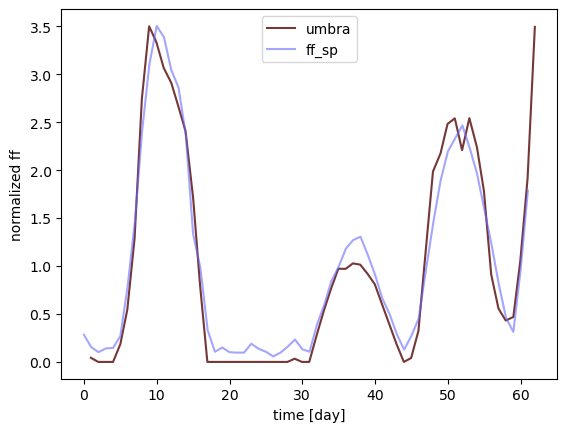

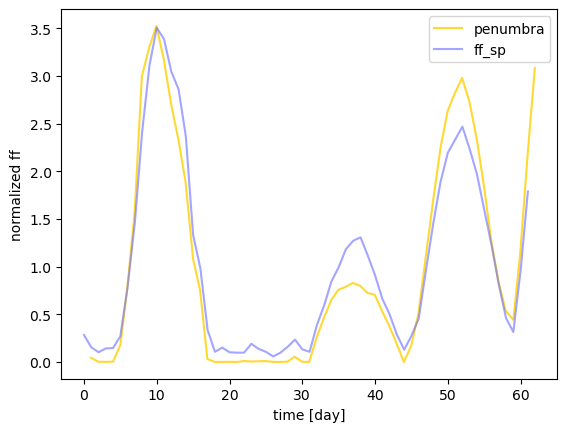

In [28]:
plt.plot(test_days_satire, (test_umbra) / np.mean(test_umbra), color = "#520505", label='umbra', alpha=0.8)
plt.plot(test_ff_sp / np.mean(test_ff_sp),  color="#686aff", alpha=0.6, label='ff_sp')
plt.legend()
plt.ylabel('normalized ff')
plt.xlabel('time [day]')
plt.show()

plt.plot(test_days_satire, (test_penumbra) / np.mean(test_penumbra), color = "#ffd000", label='penumbra', alpha=0.8)
plt.plot(test_ff_sp / np.mean(test_ff_sp),  color="#686aff", alpha=0.6, label='ff_sp')
plt.legend()
plt.ylabel('normalized ff')
plt.xlabel('time [day]')
plt.show()